# Laptop Price Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("laptop.csv") 

In [3]:
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [4]:
df.duplicated().sum()

0

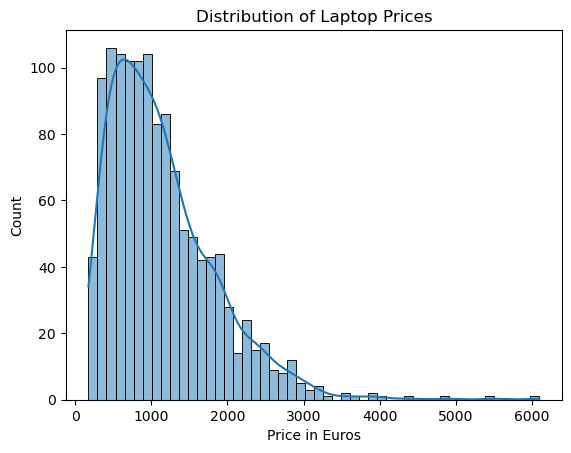

In [19]:
# Distribution of prices
import seaborn as sns
sns.histplot(df['Price_euros'], bins=50, kde=True)
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price in Euros')
plt.show()

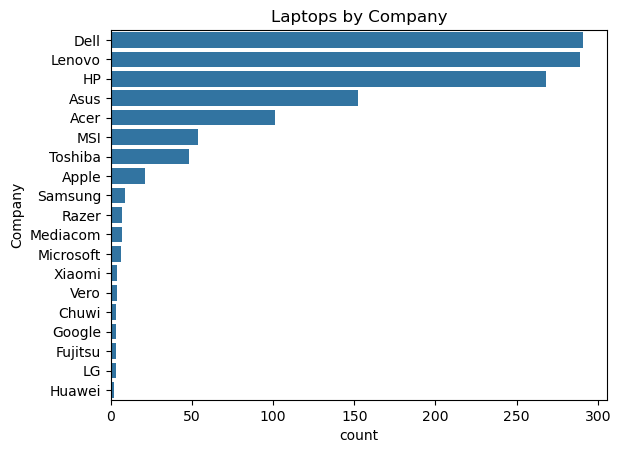

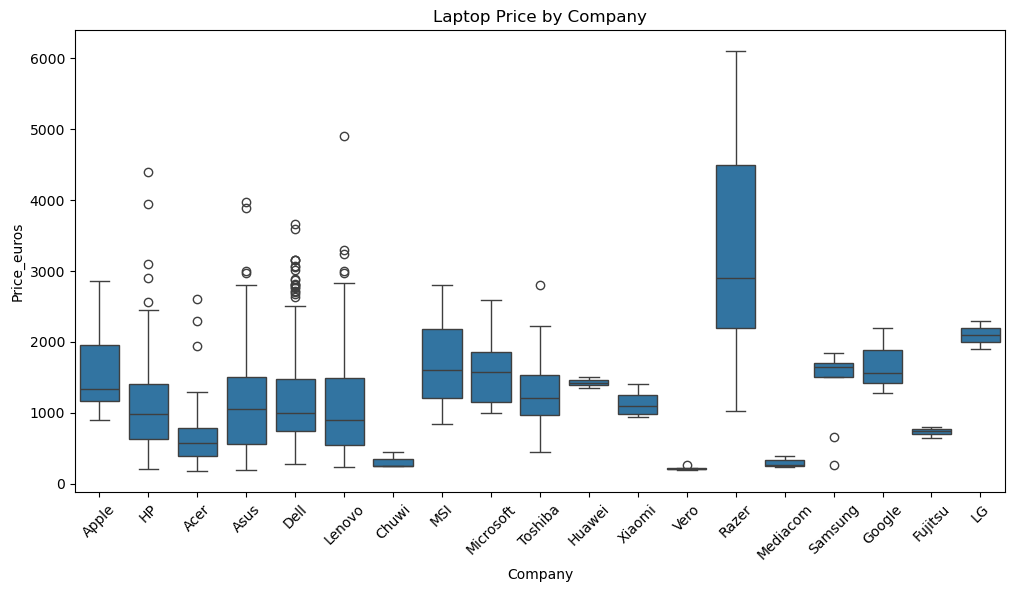

In [21]:
# Countplot of Company
sns.countplot(data=df, y='Company', order=df['Company'].value_counts().index)
plt.title('Laptops by Company')
plt.show()

# Boxplot: Price vs Company
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Company', y='Price_euros')
plt.xticks(rotation=45)
plt.title('Laptop Price by Company')
plt.show()


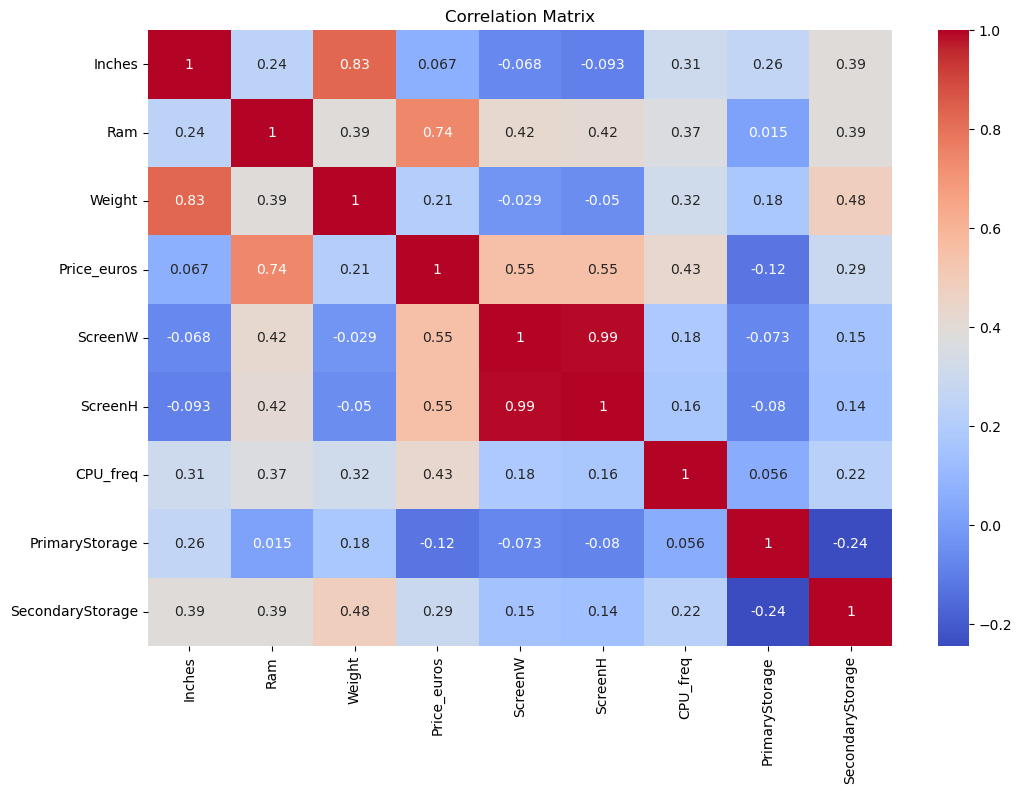

In [22]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


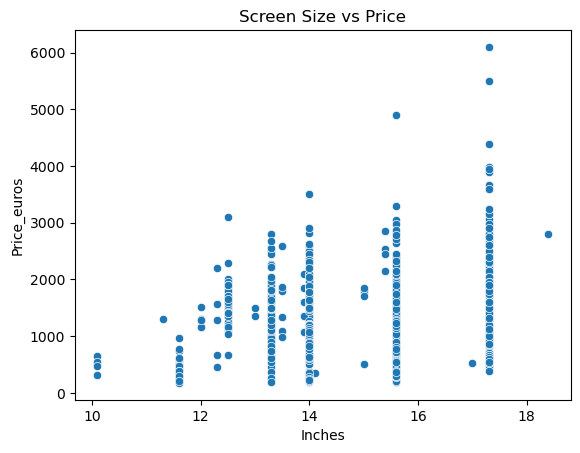

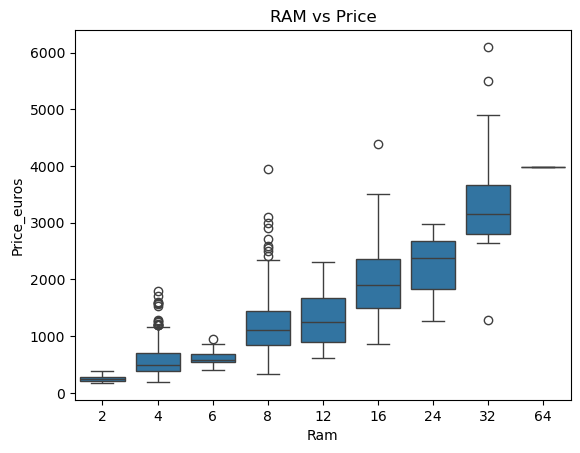

In [23]:
# Inches vs Price
sns.scatterplot(x='Inches', y='Price_euros', data=df)
plt.title('Screen Size vs Price')
plt.show()

# RAM vs Price
sns.boxplot(x='Ram', y='Price_euros', data=df)
plt.title('RAM vs Price')
plt.show()


In [24]:
binary_cols = ['Touchscreen', 'IPSpanel', 'RetinaDisplay']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title().map({'Yes': 1, 'No': 0})

In [25]:
categorical_features = ['Company', 'TypeName', 'OS', 'PrimaryStorageType',
                        'SecondaryStorageType', 'CPU_company', 'GPU_company',
                        'Screen', 'Product', 'CPU_model', 'GPU_model']
numeric_features = ['Inches', 'Ram', 'Weight', 'CPU_freq',
                    'PrimaryStorage', 'SecondaryStorage', 'ScreenW', 'ScreenH']

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Keeps binary columns
)

In [27]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [29]:
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Inches', 'Ram', 'Weight',
                                                   'CPU_freq', 'PrimaryStorage',
                                                   'SecondaryStorage',
                                                   'ScreenW', 'ScreenH']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Company', 'TypeName', 'OS',
                                                   'PrimaryStorageType',
                                                   'SecondaryStorageType',
                                                   'CPU_company', 'GPU_company',
                                                   'Screen', 'Product',
                                                   'CPU_model',
                                                   'GPU_model'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [32]:
y_pred = model_pipeline.predict(X_test)

In [34]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 65493.283203385974
R2 Score: 0.8680473487945131


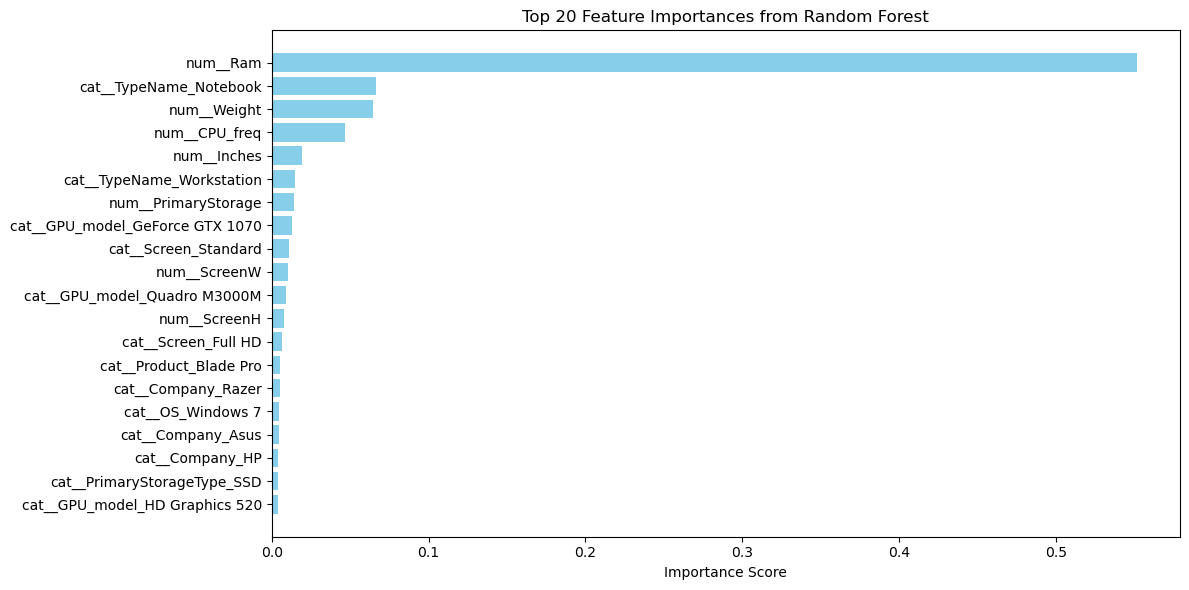

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained RandomForestRegressor
importances = regressor.feature_importances_

# Get feature names from the ColumnTransformer (after one-hot encoding)
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)  # Top 20

# Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


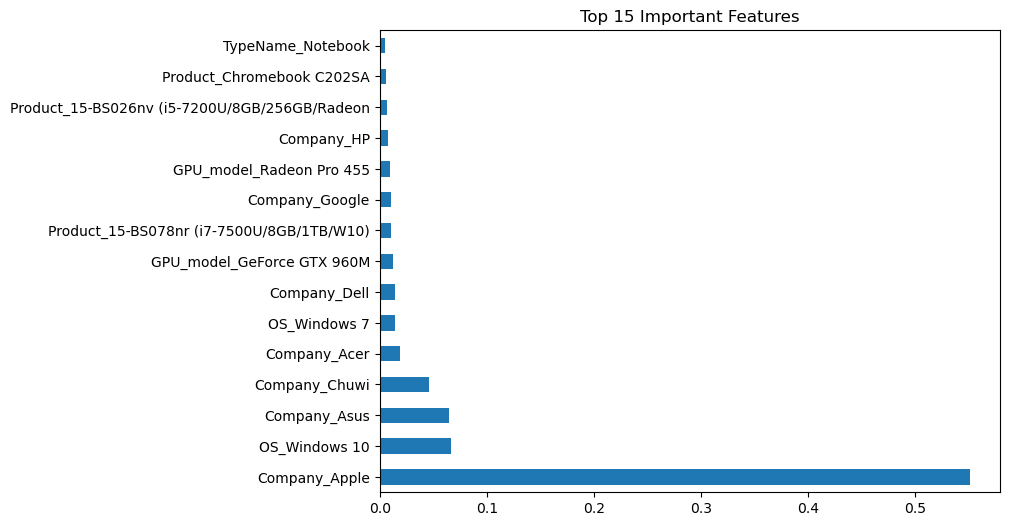

In [41]:
# Access the trained regressor inside the pipeline
regressor = model_pipeline.named_steps['regressor']
importances = regressor.feature_importances_

# Get feature names after encoding
ohe = preprocessor.named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)
feature_names = list(encoded_cat_features) + numeric_features + ['Touchscreen', 'IPSpanel', 'RetinaDisplay']

# Plot feature importances
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(15).plot(kind='barh', figsize=(8, 6))
plt.title("Top 15 Important Features")
plt.show()